# Ejercicios regresion lineal multiple

 - Importa el csv vehicles (Con todas las variables no uses vehicles_simple!!!)
 - Analiza el tipo de variables con un describe para ver su dominio, media y dispersión
 - Renombra las variables sustituyendo barras y espacios por guiones bajos
 - Realiza un análisis descriptivo antes de comenzar a entrenar el modelo puede que haya que hacer alguna limpieza previa (por ejemplo pinta un scatterplot con CO2 Emissions y Engine_Displacement, ¿Qué ocurre con los vehículos electricos?)
 - Gestiona las variables discretas: agrupa las categorías en las 2 ó 3 más importantes y transforma a dummy
 - Divide en entrenamiento y test
 - Estandariza las variables continuas
 - Entrena el mejor modelo de regresión lineal que puedas usando solo 3 ó 4 variables (o grupos de variables en el caso de las dummy)
 - Usa RandomForestRegressor para entrenar un modelo de predicción de variable dependiente continua y compáralo con la regresión lineal

In [2]:
import pandas as pd

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [4]:
df = pd.read_csv('./vehicles.csv', sep = ';')
df.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [6]:
df.describe()


,Year,Engine Displacement,Cylinders,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
count,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000
mean,2000.716460,3.338084,5.764621,17.607261,17.647655,23.882839,19.931028,475.268113,1892.330699
std,10.085477,1.359297,1.755234,4.466494,4.769072,5.890153,5.112055,119.039097,506.730622
min,1984.000000,0.600000,2.000000,0.060000,6.000000,9.000000,7.000000,37.000000,600.000000
25%,1991.000000,2.200000,4.000000,14.699423,15.000000,20.000000,16.000000,395.000000,1500.000000
50%,2001.000000,3.000000,6.000000,17.347895,17.000000,24.000000,19.000000,467.736842,1850.000000
75%,2010.000000,4.300000,6.000000,20.600625,20.000000,27.000000,23.000000,555.437500,2200.000000
max,2017.000000,8.400000,16.000000,47.087143,58.000000,61.000000,56.000000,1269.571429,5800.000000


In [8]:
# assume df is your DataFrame
df.columns = (df.columns.str.replace(r'[ /]', '_', regex=True).str.strip('-'))

In [10]:
df.head()

,Make,Model,Year,Engine_Displacement,Cylinders,Transmission,Drivetrain,Vehicle_Class,Fuel_Type,Fuel_Barrels_Year,City_MPG,Highway_MPG,Combined_MPG,CO2_Emission_Grams_Mile,Fuel_Cost_Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


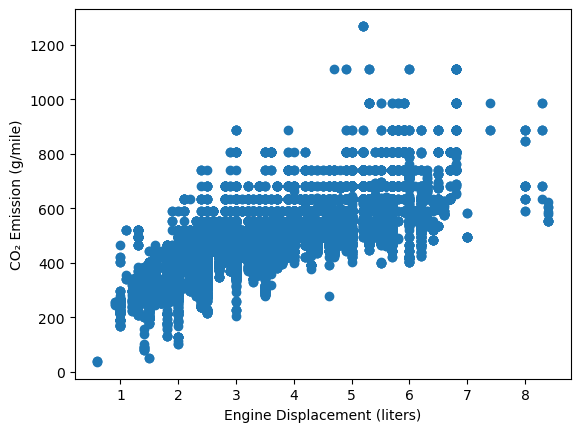

In [14]:
import matplotlib.pyplot as plt


x = df['Engine_Displacement']
y = df['CO2_Emission_Grams_Mile']

plt.xlabel('Engine Displacement (liters)') 
plt.ylabel('CO₂ Emission (g/mile)')  

plt.scatter(x, y)
plt.show()

In [16]:
df.Make.value_counts()

Chevrolet                           3643
Ford                                2946
Dodge                               2360
GMC                                 2347
Toyota                              1836
                                    ... 
Panos                                  1
Panoz Auto-Development                 1
Excalibur Autos                        1
Environmental Rsch and Devp Corp       1
Qvale                                  1
Name: Make, Length: 123, dtype: int64

In [18]:
df.Fuel_Type.value_counts()

Regular                        23585
Premium                         9913
Gasoline or E85                 1195
Diesel                           911
Premium or E85                   121
Midgrade                          74
CNG                               60
Premium and Electricity           20
Gasoline or natural gas           20
Premium Gas or Electricity        17
Regular Gas and Electricity       16
Gasoline or propane                8
Regular Gas or Electricity         2
Name: Fuel_Type, dtype: int64

In [22]:
df.Transmission.value_counts()

Automatic 4-spd                     10575
Manual 5-spd                         7787
Automatic (S6)                       2631
Automatic 3-spd                      2597
Manual 6-spd                         2423
Automatic 5-spd                      2171
Automatic 6-spd                      1432
Manual 4-spd                         1306
Automatic (S8)                        960
Automatic (S5)                        822
Automatic (variable gear ratios)      675
Automatic 7-spd                       662
Automatic (S7)                        261
Auto(AM-S7)                           256
Automatic 8-spd                       243
Automatic (S4)                        229
Auto(AM7)                             157
Auto(AV-S6)                           145
Auto(AM6)                             110
Auto(AM-S6)                            92
Automatic 9-spd                        90
Manual 3-spd                           74
Manual 7-spd                           68
Auto(AV-S7)                       

In [24]:
df.Drivetrain.value_counts()

Front-Wheel Drive             13043
Rear-Wheel Drive              12722
4-Wheel or All-Wheel Drive     6498
All-Wheel Drive                2039
4-Wheel Drive                  1058
2-Wheel Drive                   423
Part-time 4-Wheel Drive         158
2-Wheel Drive, Front              1
Name: Drivetrain, dtype: int64

In [26]:
df.Vehicle_Class.value_counts()

Compact Cars                          5185
Subcompact Cars                       4374
Midsize Cars                          4063
Standard Pickup Trucks                2311
Sport Utility Vehicle - 4WD           2081
Two Seaters                           1784
Large Cars                            1741
Sport Utility Vehicle - 2WD           1615
Special Purpose Vehicles              1402
Small Station Wagons                  1371
Minicompact Cars                      1212
Standard Pickup Trucks 2WD            1138
Vans                                  1121
Standard Pickup Trucks 4WD             956
Midsize-Large Station Wagons           633
Special Purpose Vehicle 2WD            581
Small Pickup Trucks                    523
Small Sport Utility Vehicle 4WD        494
Vans, Cargo Type                       432
Midsize Station Wagons                 416
Standard Sport Utility Vehicle 4WD     409
Small Pickup Trucks 2WD                401
Small Sport Utility Vehicle 2WD        374
Minivan - 2